In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/kenya.csv")
df["Country"] = "Ethiopia"

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/kenya.csv'

In [3]:
df = pd.read_csv("../data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4108 entries, 0 to 4107
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4108 non-null   int64  
 1   DOY          4108 non-null   int64  
 2   T2M          4108 non-null   float64
 3   T2M_MAX      4108 non-null   float64
 4   T2M_MIN      4108 non-null   float64
 5   T2M_RANGE    4108 non-null   float64
 6   PRECTOTCORR  4108 non-null   float64
 7   RH2M         4108 non-null   float64
 8   WS2M         4108 non-null   float64
 9   WS2M_MAX     4108 non-null   float64
 10  PS           4108 non-null   float64
 11  QV2M         4108 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.3 KB


In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


In [6]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

In [7]:
df = df.replace(-999, np.nan)

In [8]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

In [9]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,2015-01-05,1


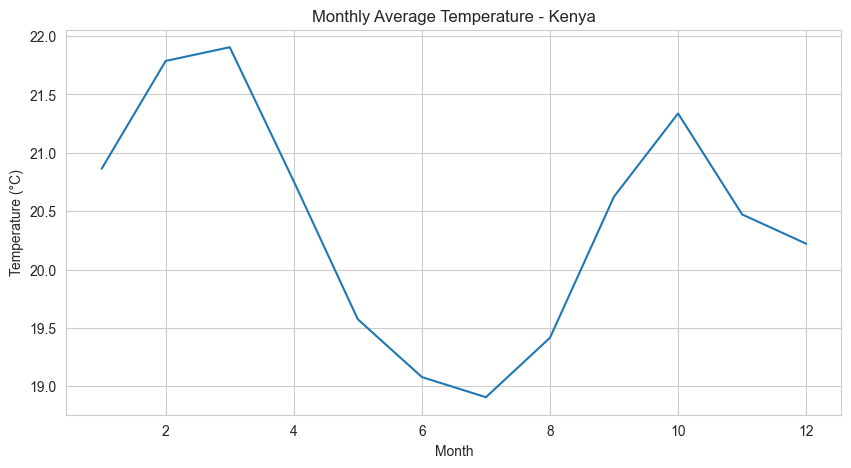

In [12]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(figsize=(10,5))
plt.title("Monthly Average Temperature - Kenya")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()

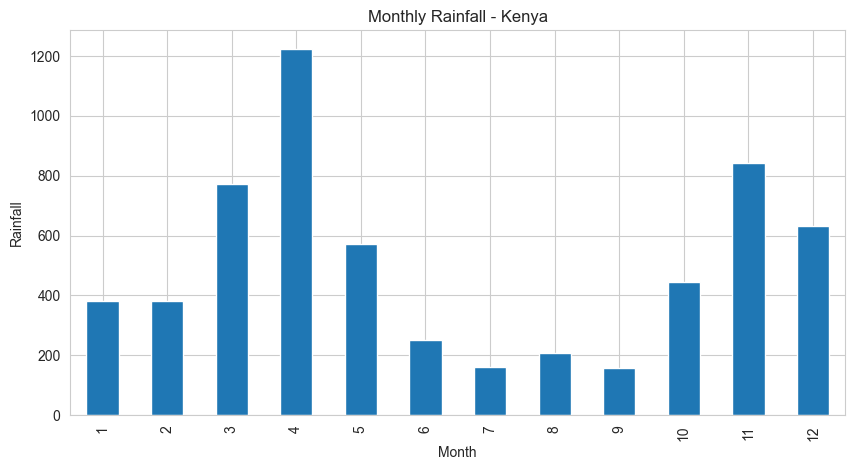

In [13]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5))
plt.title("Monthly Rainfall - Kenya")
plt.xlabel("Month")
plt.ylabel("Rainfall")
plt.show()

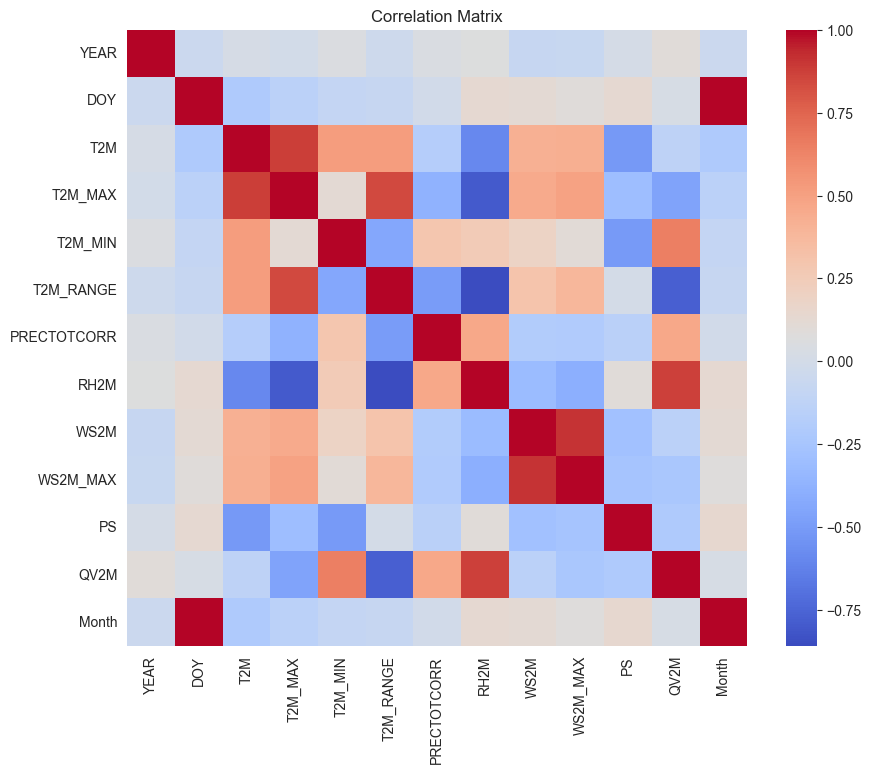

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

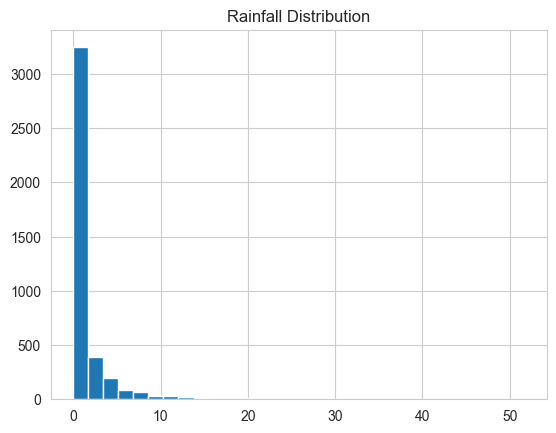

In [15]:
plt.hist(df["PRECTOTCORR"].dropna(), bins=30)
plt.title("Rainfall Distribution")
plt.show()

## Key Insights
- Temperature shows seasonal variation
- Rainfall is concentrated in specific months
- Some variables are strongly correlated